In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

ModuleNotFoundError: No module named 'tensorflow'

In [4]:
!pip install tensorflow

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   - -------------------------------------- 8.9/331.9 MB 55.5 MB/s eta 0:00:06
   -- ------------------------------------- 21.8/331.9 MB 59.9 MB/s eta 0:00:06
   ---- ----------------------------------- 38.0/331.9 MB 65.3 MB/s eta 0:00:05
   ------ --------------------------------- 53.2/331.9 MB 67.8 MB/s eta 0:00:05
   -------- ------------------------------- 70.5/331.9 MB 70.3 MB/s eta 0:00:04
   ---------- ----------------------------- 86.0/331.9 MB 71.3 MB/s eta 0:00:04
   ----------- --------------------------- 100.1/331.9 MB 71.0 MB/s eta 0:00:04
   ------------- ------------------------- 113.2/331.9 MB 70.2 MB/s eta 0:00:04
   -------------- ------------------------ 127.4/331.9 MB 68.9 MB/s eta 0:00:03
   ---------------- ---------------------- 141.8/331.9 MB 68.7 MB/s eta 0:00:03
   ------------------ -------------------- 157.8/331.9 MB 69.1 MB/s eta 0:00:03
   -------------------- ------------------ 171.4/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [6]:
!pip install numpy

In [8]:
!pip install pandas

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [12]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Create a simple model
model = Sequential([
    Input((28, 28)),
    Flatten(), # need to flatten 28x28 image matrices into vectors
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # softmax output activation for multi-class
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # categorical not binary for multi-class
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=5,               # Number of epochs with no improvement after which to stop
    min_delta=0.001,          # Minimum change to qualify as improvement
    restore_best_weights=True # Restore model weights from the epoch with the best value
)

# Model checkpoint callback to save the best model
checkpoint_filepath = './best_model.keras'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,      # Only save when there's improvement
    mode='min',               # The direction is 'min' for loss
    verbose=1                 # Show progress
)

# TensorBoard callback for visualization
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1          # Update histograms every epoch
)

# Combine callbacks into a list
callbacks = [
    early_stopping,
    model_checkpoint,
    tensorboard_callback
]

In [18]:
# Train the model with callbacks
history = model.fit(
    x_train, y_train,
    epochs=100,                # Set a high number, early stopping will halt training if needed
    batch_size=128,
    validation_split=0.2,     # Use 20% of training data for validation
    callbacks=callbacks,      # Pass the callbacks list here
    verbose=1
)

Epoch 1/100
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8238 - loss: 0.6593
Epoch 1: val_loss improved from None to 0.18881, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9000 - loss: 0.3657 - val_accuracy: 0.9453 - val_loss: 0.1888
Epoch 2/100
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9493 - loss: 0.1733
Epoch 2: val_loss improved from 0.18881 to 0.14524, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9539 - loss: 0.1586 - val_accuracy: 0.9550 - val_loss: 0.1452
Epoch 3/100
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9635 - loss: 0.1207
Epoch 3: val_loss improved from 0.14524 to 0.12495, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9664 - loss: 0.1126 - val_accuracy: 0.9613 - val_loss: 0.1250
Epoch 4/100
369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9726 - loss: 0.0920
Epoch 4: val_loss improved from 0.12495 to

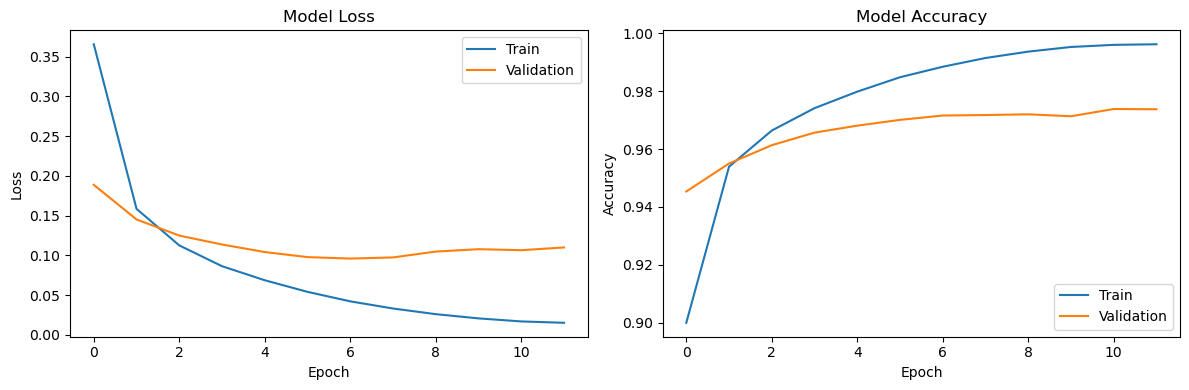

Training stopped at epoch 12


In [22]:
# Plot training & validation loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.tight_layout()
plt.show()

# Print the epoch where training stopped
print(f"Training stopped at epoch {len(history.history['loss'])}")


In [24]:
# In your notebook or Python script, run:
%load_ext tensorboard
%tensorboard --logdir=logs/fit

In [26]:
# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model(checkpoint_filepath)

# Evaluate on test data
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 2s - 5ms/step - accuracy: 0.9759 - loss: 0.0852
Test accuracy: 0.9759


In [28]:
# Add a callback to monitor gradient norms
class GradientMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        grads = self.model.optimizer.get_gradients(self.model.total_loss, self.model.trainable_weights)
        norm = tf.sqrt(sum([tf.reduce_sum(tf.square(g)) for g in grads]))
        print(f"Epoch {epoch}: Gradient norm: {norm}")
        
# Add this to your callbacks list
gradient_monitor = GradientMonitor()
callbacks.append(gradient_monitor)

In [30]:
# Apply gradient clipping when compiling the model
from tensorflow.keras.optimizers import Adam

optimizer = Adam(clipnorm=1.0)  # Clip gradients to a maximum norm of 1
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
# Add ReduceLROnPlateau callback
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,            # Reduce learning rate by 80%
    patience=3,            # Wait 3 epochs of no improvement
    min_lr=0.00001         # Don't go below this learning rate
)
callbacks.append(reduce_lr)

In [34]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Input((28, 28)),
    Flatten(),
    Dense(128),
    BatchNormalization(),  # Add batch normalization after Dense layers
    Activation('relu'),    # Activation function applied after normalization
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])

NameError: name 'Activation' is not defined

In [36]:
# Try LeakyReLU instead of regular ReLU
from tensorflow.keras.layers import LeakyReLU

model = Sequential([
    Input((28, 28)),
    Flatten(),
    Dense(128),
    LeakyReLU(alpha=0.1),  # LeakyReLU allows small negative values
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dense(10, activation='softmax')
])

C:\Users\12146\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [38]:
# Use He initialization for ReLU networks
model = Sequential([
    Input((28, 28)),
    Flatten(),
    Dense(128, kernel_initializer='he_normal'),
    Activation('relu'),
    Dense(64, kernel_initializer='he_normal'),
    Activation('relu'),
    Dense(10, activation='softmax')
])

NameError: name 'Activation' is not defined